# Executive Summary

**Objective:** The goal of this project is to reverse-engineer and validate the scoring system of a fantasy baseball league. By applying a machine learning model to historical player statistics, we can identify the exact weight (point value) assigned to specific baseball events (Innings Pitched, Strikeouts, Saves, Holds etc.).

**Methodology:**
* **Data Preprocessing:** Standardized historical player statistics using Z-scores to ensure features with larger raw numbers (e.g., Inning Pitched) do not disproportionately dominate the model. Removed extreme outliers to prevent skewing during the training phase.
* **Modeling:** Implemented a Lasso Regression model with 5-fold Cross-Validation (`LassoCV`). Lasso was chosen for its ability to perform automatic feature selection by driving irrelevant feature coefficients to zero, ensuring we isolate only the metrics that actually contribute to fantasy points.

**Results:**
The model achieved an $R^2$ score of ~1.0, successfully capturing the exact linear formula used to calculate Fantasy Points. The resulting coefficients perfectly align with standard league scoring (e.g., heavily reward Saves, Holds, and Strikeouts, while penalizing Blowns Saves and Earned Runs).

## Import Packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.linear_model import lasso_path

## Load Data

In [2]:
# Use Pandas to read in Relievers (Relief Pitchers) Historical Data
RelieversHistorical = pd.read_csv("../HistoricalData/RelieversHistorical.csv")

# Display the first few rows to verify
RelieversHistorical.head()

,Year,Player Name,Position,Team,Innings Pitched (IP),Hits Allowed (H),Earned Runs (ER),Walks Issued (BB),Strikeouts (K),Saves (SV),Blown Saves (BS),Holds (HD),Fantasy Points (FPTS)
0,2024,Emmanuel Clase,RP,Cleveland Guardians,74.333333,39,5,10,66,47,3,0,609.5
1,2024,Ryan Helsley,RP,St. Louis Cardinals,66.333333,50,15,23,79,49,4,0,541.5
2,2025,Abner Uribe,RP,Milwaukee Brewers,75.333333,51,14,27,90,7,2,37,530.0
3,2025,Aroldis Chapman,RP,Boston Red Sox,61.333333,28,8,15,85,32,2,4,500.0
4,2024,Nick Martinez,RP,Cincinnati Reds,142.333333,128,49,18,116,0,0,7,498.5


## Standardize Data (Numerical Predictors Only)

#### Seperate Numerical Predictors

In [3]:
# Numerical Predictor Variables only
PredictorVariables = RelieversHistorical[['Innings Pitched (IP)', 'Hits Allowed (H)', 'Earned Runs (ER)', 'Walks Issued (BB)', 
                                         'Strikeouts (K)', 'Saves (SV)', 'Blown Saves (BS)', 'Holds (HD)']]

# Display the first few rows to verify
PredictorVariables.head()

,Innings Pitched (IP),Hits Allowed (H),Earned Runs (ER),Walks Issued (BB),Strikeouts (K),Saves (SV),Blown Saves (BS),Holds (HD)
0,74.333333,39,5,10,66,47,3,0
1,66.333333,50,15,23,79,49,4,0
2,75.333333,51,14,27,90,7,2,37
3,61.333333,28,8,15,85,32,2,4
4,142.333333,128,49,18,116,0,0,7


#### Standardize Numerical Data

In [4]:
# Initialize the StandardScalar
scaler = StandardScaler()

# Compute the mean and std dev of the predictors, then apply the transformation
PredictorVariables_ZScore = scaler.fit_transform(PredictorVariables)

#### Print Standardization Results

In [5]:
# Collect all the PredictorVariables columns
cols = PredictorVariables.columns

# Mean     (scaler.mean_): Represents the center of the distribution.
# Variance (scaler.var_) : Represents how much the data varies from the mean (High variance = Large difference between lowest value and highest value).

# Create a clean DataFrame of the statistics
df = pd.DataFrame({
    'Mean': scaler.mean_,
    'Variance': scaler.var_
}, index=cols)

print("Feature Statistics for Scaling:")
print(df.round(2)) # Rounds all columns to 2 decimal places

Feature Statistics for Scaling:
                       Mean  Variance
Innings Pitched (IP)  71.66    249.20
Hits Allowed (H)      52.72    320.86
Earned Runs (ER)      21.30     90.44
Walks Issued (BB)     22.99     66.90
Strikeouts (K)        82.05    370.65
Saves (SV)            16.42    203.04
Blown Saves (BS)       3.94      4.07
Holds (HD)            14.40    151.98


#### Convert PredictorVariables back to DataFrame

In [6]:
# Convert the scaled array back to a DataFrame so we keep labels
PredictorVariables_ZScore_DF = pd.DataFrame(PredictorVariables_ZScore, columns = PredictorVariables.columns, index = PredictorVariables.index)

# Display the shape of the DF (rows, cols)
print(f"Dataframe sape is: {PredictorVariables_ZScore_DF.shape}")

Dataframe sape is: (106, 8)


# Data Preprocessing: Handling Outliers & Scaling

Before training the model, the data must be standardized. Because regularized regression models (like Lasso) apply a penalty to the coefficients, it is crucial that all features are on the same scale so the penalty is applied uniformly. 

Additionally, we identify and remove extreme outliers (Z-score > 3 or < -3). While these represent statistically valid "superstar" seasons rather than erroneous data, removing them ensures our model's line of best fit is optimized for the vast majority of the player pool rather than being overly warped by historic statistical anomalies. After filtering, we re-standardize the clean dataset to prevent data leakage and ensure an accurate baseline.

## Outliers

#### Determine Outliers

In [7]:
# Set Dependent Variable
Y = RelieversHistorical['Fantasy Points (FPTS)']

# Identify the rows where ANY column with outliers (Z-score > 3 or < -3)
Outliers = (PredictorVariables_ZScore_DF.abs() > 3).any(axis=1)

# Print how many rows we are removing (just for context)
print(f"There are {Outliers.sum()} outlier rows.")

There are 5 outlier rows.


#### Remove Outliers

In [8]:
# Filter your datasets to keep only the "good" data (the non-outliers)
# ~ == "NOT outliers"
X = PredictorVariables[~Outliers]
Y = Y[~Outliers]

# Print how many rows we are removing (just for context)
print(f"Removed {Outliers.sum()} outlier rows.")

# Display the shape of the DF to ensure columns were removed (rows, cols)
print(f"New dataframe shape is: {X.shape}")

Removed 5 outlier rows.
New dataframe shape is: (101, 8)


## Re-Standardize Data

In [9]:
scaler2 = StandardScaler()

PredictorVariables_ZScore2 = scaler2.fit_transform(X)

In [10]:
# Mean     (Scaler.mean_): Represents the center of the distribution.
# Variance (Scaler.var_) : Represents how much the data varies from the mean (High variance = Large difference between lowest value and highest value).

# Create a clean DataFrame of the statistics
df = pd.DataFrame({
    'Mean': scaler2.mean_,
    'Variance': scaler2.var_
}, index=cols)

print("New Feature Statistics for Scaling (After Re-Standardizing):")
print(df.round(2)) # Rounds all columns to 2 decimal places

New Feature Statistics for Scaling (After Re-Standardizing):
                       Mean  Variance
Innings Pitched (IP)  69.03     80.22
Hits Allowed (H)      49.97    153.75
Earned Runs (ER)      19.86     41.60
Walks Issued (BB)     22.46     54.43
Strikeouts (K)        80.39    257.86
Saves (SV)            16.77    195.38
Blown Saves (BS)       3.99      3.20
Holds (HD)            14.94    152.77


In [11]:
# Convert the scaled array back to a DataFrame so we keep labels
PredictorVariables_ZScore2_DF = pd.DataFrame(PredictorVariables_ZScore2, columns = X.columns, index = X.index)

# Display the first few rows to verify
PredictorVariables_ZScore2_DF.head()

,Innings Pitched (IP),Hits Allowed (H),Earned Runs (ER),Walks Issued (BB),Strikeouts (K),Saves (SV),Blown Saves (BS),Holds (HD)
0,0.591778,-0.884726,-2.304034,-1.688321,-0.895884,2.162525,-0.553662,-1.208789
1,-0.301416,0.002395,-0.753685,0.073814,-0.086321,2.305607,0.005537,-1.208789
2,0.703427,0.083043,-0.908720,0.616009,0.598694,-0.699120,-1.112861,1.784747
3,-0.859662,-1.771847,-1.838929,-1.010577,0.287324,1.089408,-1.112861,-0.885164
5,1.001158,0.244338,0.021490,0.209363,1.470532,-0.341414,0.005537,0.732964


# Model Selection: Cross-Validated Lasso Regression

To find the exact linear weights of the fantasy scoring system, we utilize **Lasso Regression (L1 Regularization)**. Lasso is ideal here because it inherently performs feature selection. If a specific baseball statistic is not actually used in the league's point formula, Lasso will shrink its coefficient to exactly `0`, simplifying our final equation.

We implement **5-fold Cross-Validation** to find the optimal regularization parameter (Alpha/Lambda). This splits the data into 5 subsets, iteratively training on 80% and testing on 20%, ensuring our model generalizes well to unseen data and isn't over-indexing on a specific cluster of players.

## Fit/Train Linear Regression Model

In [12]:
# Initialize Lasso regression with 5-fold cross-validation to find the optimal alpha
model = LassoCV(cv=5)

# Train the model using the standardized predictors and the target variable (Y)
model.fit(PredictorVariables_ZScore2_DF, Y)

LassoCV(cv=5)

In [13]:
# Calculate R-Squared
print('R-Squared: ',model.score(PredictorVariables_ZScore2_DF, Y))

# Print the slected alpha(Lambda) that LassoCV selected as the best
print('Selected best alpha(Lambda): ',model.alpha_)

R-Squared:  0.9999918513158917
Selected best alpha(Lambda):  0.01987290814406215


## Plots

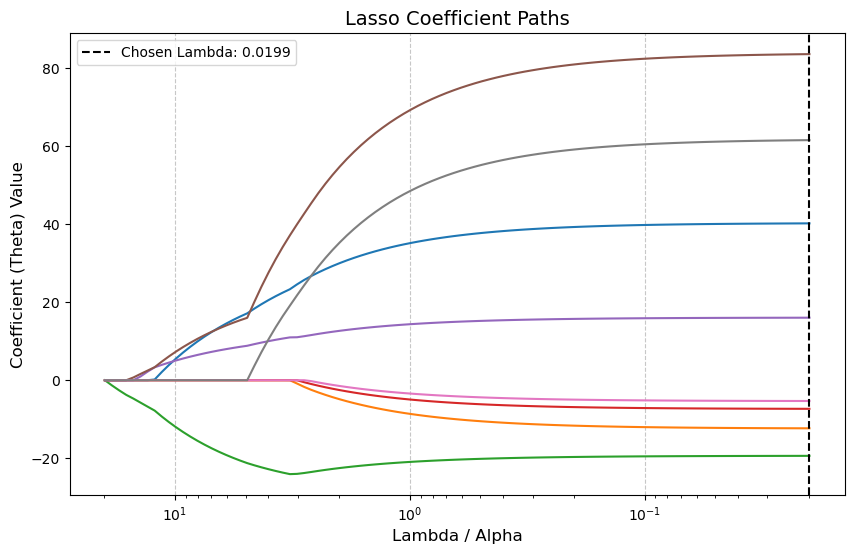

In [14]:
# ---------------------------------------------
#
#    Plot Theta of all folds
#
# ---------------------------------------------

# Compute the Lasso path using training data
alphas, coefs, _ = lasso_path(PredictorVariables_ZScore2_DF, Y)

# Set up plot
plt.figure(figsize=(10, 6))

# # Plot the Theta for each of the individual folds
for i in range(coefs.shape[0]):
    plt.plot(alphas, coefs[i, :])

# Format
plt.xscale('log') 
plt.gca().invert_xaxis()
plt.xlabel('Lambda / Alpha', fontsize=12)
plt.ylabel('Coefficient (Theta) Value', fontsize=12)
plt.title('Lasso Coefficient Paths', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add a vertical line to show where the model chose the best Lambda
plt.axvline(model.alpha_, color='black', linestyle='--', label=f'Chosen Lambda: {model.alpha_:.4f}')
plt.legend()

# Plot
plt.show()

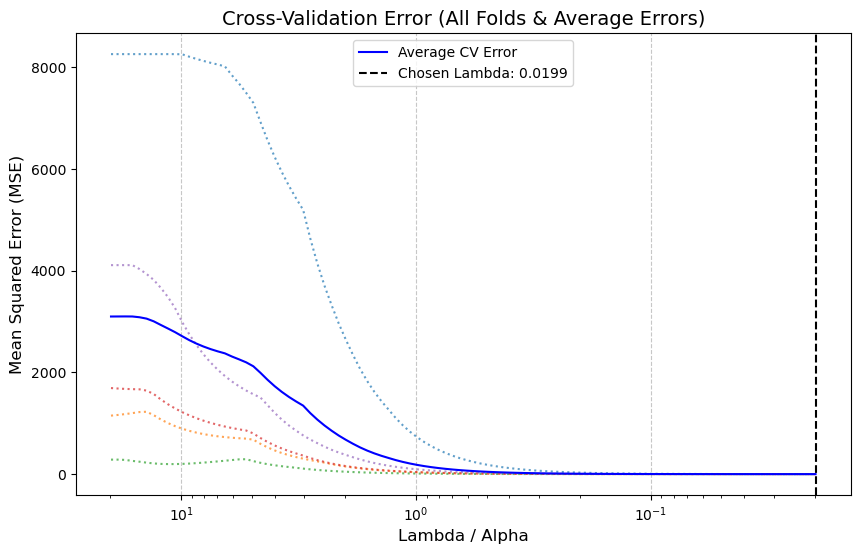

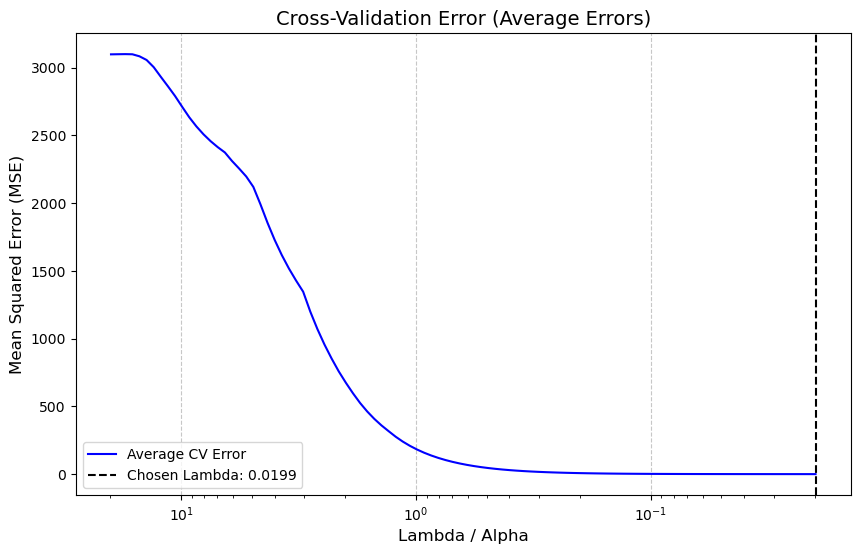

In [15]:
# ---------------------------------------------
#
#    Plot average MSE and all folds
#
# ---------------------------------------------

# Set up plot
plt.figure(figsize=(10, 6))

# Plot the MSE for each of the individual folds
plt.plot(model.alphas_, model.mse_path_, linestyle=':', alpha=0.7)

# Calculate the average Mean Squared Error (MSE) across all folds
meanMSE = model.mse_path_.mean(axis=-1)

# Plot the Average CV Error line
plt.plot(model.alphas_, meanMSE, color='blue', label='Average CV Error')

# Format
plt.xscale('log') 
plt.gca().invert_xaxis()
plt.xlabel('Lambda / Alpha', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Cross-Validation Error (All Folds & Average Errors)', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add a vertical line to show where the model chose the best Lambda
plt.axvline(model.alpha_, color='black', linestyle='--', label=f'Chosen Lambda: {model.alpha_:.4f}')
plt.legend()

# Plot
plt.show()

# ---------------------------------------------
#
#    Plot only average MSE of all folds
#
# ---------------------------------------------

# Set up plot
plt.figure(figsize=(10, 6))

# Calculate the average Mean Squared Error (MSE) across all folds
meanMSE = model.mse_path_.mean(axis=-1)

# Plot the Average CV Error line
plt.plot(model.alphas_, meanMSE, color='blue', label='Average CV Error')

# Format
plt.xscale('log') 
plt.gca().invert_xaxis()
plt.xlabel('Lambda / Alpha', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Cross-Validation Error (Average Errors)', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add a vertical line to show where the model chose the best Lambda
plt.axvline(model.alpha_, color='black', linestyle='--', label=f'Chosen Lambda: {model.alpha_:.4f}')
plt.legend()

# Plot
plt.show()

# Results & Feature Interpretation

With the optimal Lambda selected, we can extract the model's coefficients. Because our data was standardized, these coefficients represent the change in Fantasy Points for every **one standard deviation** increase in a given statistic. 

By analyzing these weights, we can clearly see the underlying scoring mechanics of the league.

## Evaluate Model

#### Calculate Standard Deviation & Print Coefficients

Amount per Standard Deviation:
Innings Pitched (IP)    15.861203
Hits Allowed (H)        17.997754
Earned Runs (ER)         9.555023
Walks Issued (BB)        8.217861
Strikeouts (K)          19.343699
Saves (SV)              14.316735
Blown Saves (BS)         2.027573
Holds (HD)              12.386382
dtype: float64
                      Coefficient (Theta)
Innings Pitched (IP)            40.199794
Hits Allowed (H)               -12.323658
Earned Runs (ER)               -19.383077
Walks Issued (BB)               -7.328447
Strikeouts (K)                  16.023741
Saves (SV)                      83.567889
Blown Saves (BS)                -5.325163
Holds (HD)                      61.527790

Intercept: 422.3910891089109


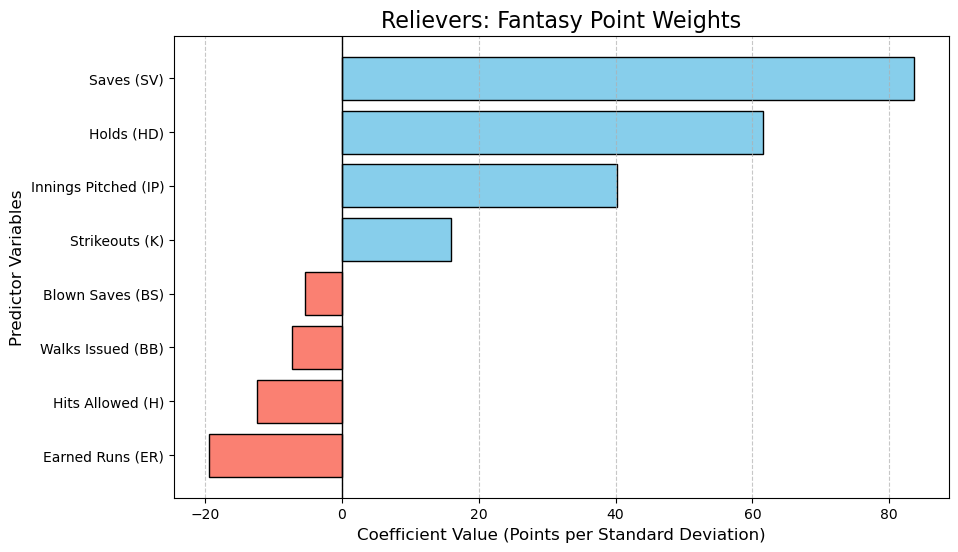

In [17]:
# Calculate the standard deviation of numerical 
print(f"Amount per Standard Deviation:\n{PredictorVariables.std()}")

# Create a DataFrame to match the coefficients with their column names
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient (Theta)'])
print(coeff_df)

# Also print the Intercept (Theta 0)
print(f"\nIntercept: {model.intercept_}")

# ---------------------------------------------
#
#    Plot Feature Importance (Coefficients)
#
# ---------------------------------------------

# Sort the DataFrame by the coefficient values so the chart looks organized
coeff_df_sorted = coeff_df.sort_values(by='Coefficient (Theta)')

# Create a horizontal bar chart
plt.figure(figsize=(10, 6))
bars = plt.barh(coeff_df_sorted.index, coeff_df_sorted['Coefficient (Theta)'], color='skyblue', edgecolor='black')

# Color negative values red for emphasis (like Earned Runs)
for bar in bars:
    if bar.get_width() < 0:
        bar.set_color('salmon')
        bar.set_edgecolor('black')

# Format the plot
plt.title('Relievers: Fantasy Point Weights', fontsize=16)
plt.xlabel('Coefficient Value (Points per Standard Deviation)', fontsize=12)
plt.ylabel('Predictor Variables', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add a vertical line at 0 for reference
plt.axvline(0, color='black', linewidth=1)

plt.show()